# Training

## Initialization

In [75]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [76]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, recall_score, f1_score, precision_score

from src import utils

In [77]:
X_train = utils.deserialize_data("data/processed/X_train_prep.pkl")
y_train = utils.deserialize_data("data/processed/y_train_prep.pkl")
X_valid = utils.deserialize_data("data/processed/X_valid_prep.pkl")
y_valid = utils.deserialize_data("data/interim/y_valid.pkl")

## Train

In [78]:
params_lr = {
    'C': [0.1, 1.0],
    'solver': ['saga', 'liblinear'],
    'max_iter': [10000]
}

params_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15]
}

params_xgb = {
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200]
}

In [79]:
def train_model(model, param_grid, X, y):
    """
    Melakukan hyperparameter tuning menggunakan GridSearchCV.
    
    Parameters:
    model: Instance model ML
    param_grid: Dictionary hyperparameter
    X: Data fitur latih
    y: Target latih
    
    Returns:
    grid_search: Instance GridSearchCV yang telah dilatih
    """
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        n_jobs=-1,
        verbose=3,
        cv=3
    )
    grid_search.fit(X, y)
    return grid_search

models_to_train = [
    (LogisticRegression(random_state=42), params_lr, LogisticRegression.__name__),
    (RandomForestClassifier(random_state=42), params_rf, RandomForestClassifier.__name__),
    (XGBClassifier(random_state=42), params_xgb, XGBClassifier.__name__)
]

trained_models = {}

for model_obj, params, name in models_to_train:
    print(f"Training {name}...")
    best_model = train_model(model_obj, params, X_train, y_train)
    trained_models[name] = best_model
    utils.serialize_data(best_model, f"model/{name}_best.pkl") # type: ignore

Training LogisticRegression...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Data serialized on model/LogisticRegression_best.pkl.
Training RandomForestClassifier...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Data serialized on model/RandomForestClassifier_best.pkl.
Training XGBClassifier...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Data serialized on model/XGBClassifier_best.pkl.


## Threshold Tuning

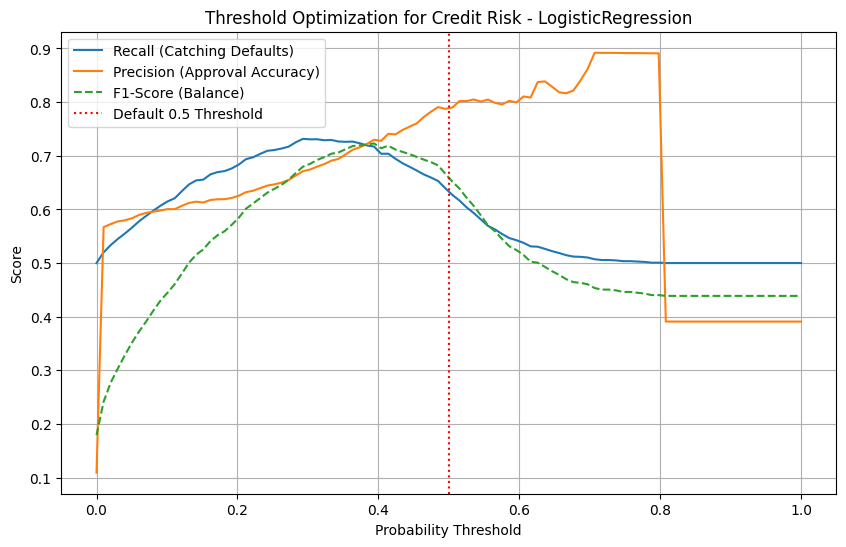

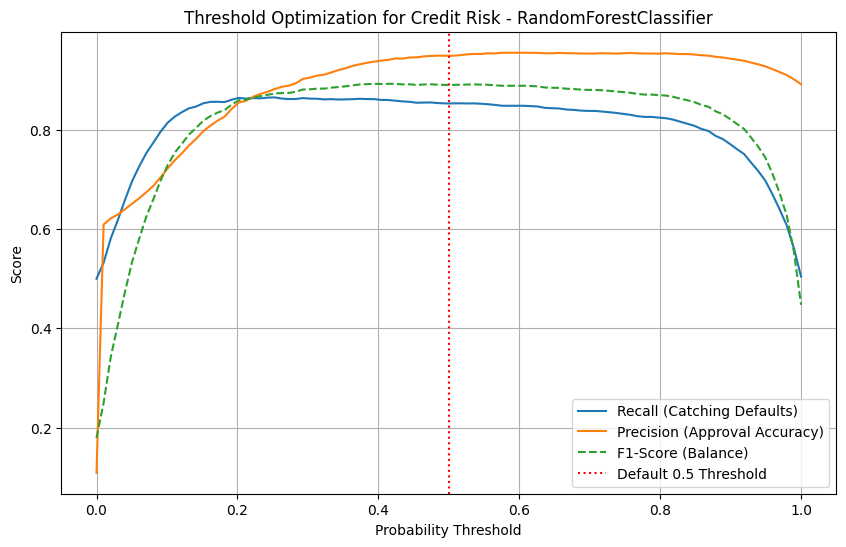

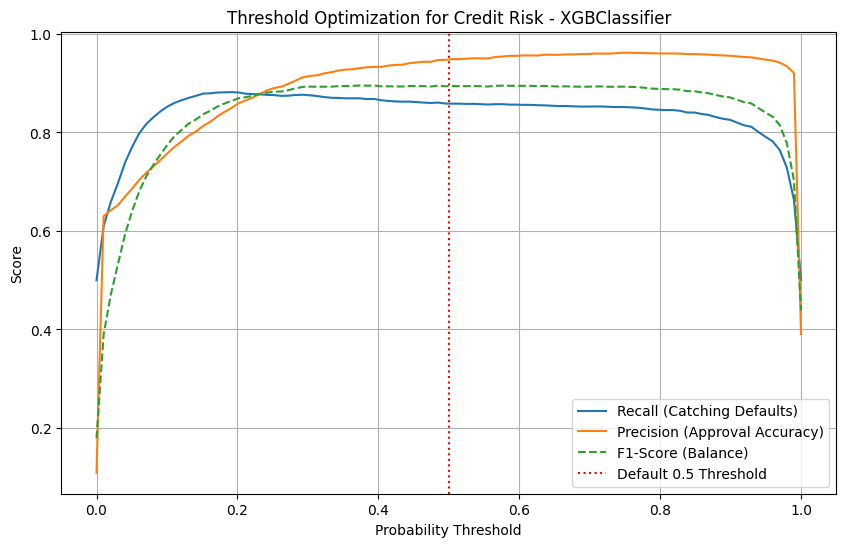

In [80]:
def get_threshold_tuning(model, X_val, y_val, metric_name='recall'):
    """
    Finds the best threshold for credit risk prediction, prioritizing Recall 
    to minimize missed defaults (False Negatives).
    """
    thresholds = np.linspace(0, 1, 100)
    results = []

    y_prob = model.predict_proba(X_val)[:, 1]

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        recall = recall_score(y_val, y_pred, average='macro')
        precision = precision_score(y_val, y_pred, zero_division=0, average='macro')
        f1 = f1_score(y_val, y_pred, average='macro')

        if metric_name == 'recall':
            score = recall
        elif metric_name == 'precision':
            score = precision
        else:
            score = f1

        results.append({
            'threshold': t,
            'recall': recall,
            'precision': precision,
            'f1_score': f1,
            'metric_value': score,
            'model_name': type(model.best_estimator_).__name__
        })

    plt.figure(figsize=(10, 6))
    sns.lineplot(x=[r['threshold'] for r in results], y=[r['recall'] for r in results], label='Recall (Catching Defaults)')
    sns.lineplot(x=[r['threshold'] for r in results], y=[r['precision'] for r in results], label='Precision (Approval Accuracy)')
    sns.lineplot(x=[r['threshold'] for r in results], y=[r['f1_score'] for r in results], label='F1-Score (Balance)', linestyle='--')
    
    plt.axvline(x=0.5, color='red', linestyle=':', label='Default 0.5 Threshold')
    plt.title(f"Threshold Optimization for Credit Risk - {type(model.best_estimator_).__name__}")
    plt.xlabel("Probability Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return results

all_threshold_results = []
for name, model in trained_models.items():
    res = get_threshold_tuning(model, X_valid, y_valid)
    all_threshold_results.append(res)

In [81]:
def select_best_threshold(list_of_results, save_path):
    """
    Menggabungkan hasil tuning dan memilih yang terbaik untuk disimpan ke JSON.
    """
    df_results = pd.concat([pd.DataFrame(res) for res in list_of_results])
    df_results = df_results.sort_values(by='metric_value', ascending=False)
    best_config = df_results.iloc[0].to_dict()
    with open(save_path, 'w') as f:
        json.dump(best_config, f)
    return best_config

best_threshold_config = select_best_threshold(all_threshold_results, "model/best_threshold.json")

In [82]:
best_threshold_config

{'threshold': 0.19191919191919193,
 'recall': 0.8816975046343924,
 'precision': 0.850045450747342,
 'f1_score': 0.8641783641160949,
 'metric_value': 0.8816975046343924,
 'model_name': 'XGBClassifier'}

In [83]:
trained_models

{'LogisticRegression': GridSearchCV(cv=3, estimator=LogisticRegression(random_state=42), n_jobs=-1,
              param_grid={'C': [0.1, 1.0], 'max_iter': [10000],
                          'solver': ['saga', 'liblinear']},
              verbose=3),
 'RandomForestClassifier': GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
              param_grid={'max_depth': [5, 10, 15], 'n_estimators': [100, 200]},
              verbose=3),
 'XGBClassifier': GridSearchCV(cv=3,
              estimator=XGBClassifier(base_score=None, booster=None,
                                      callbacks=None, colsample_bylevel=None,
                                      colsample_bynode=None,
                                      colsample_bytree=None, device=None,
                                      early_stopping_rounds=None,
                                      enable_categorical=False, eval_metric=None,
                                      feature_types=None, feature_we

## Model Evaluation

In [84]:
def evaluate_model(model, threshold_config, X_test, y_test):
    """
    Evaluasi model akhir menggunakan data test dan threshold terpilih.
    """
    threshold = threshold_config['threshold']
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    
    print(f"Evaluation for Model: {threshold_config['model_name']}")
    print(f"Using Threshold: {threshold}")
    print(classification_report(y_test, y_pred))

X_test = utils.deserialize_data("data/processed/X_test_prep.pkl")
y_test = utils.deserialize_data("data/interim/y_test.pkl")

best_model_name = best_threshold_config['model_name']
evaluate_model(trained_models[best_model_name], best_threshold_config, X_test, y_test)

Evaluation for Model: XGBClassifier
Using Threshold: 0.19191919191919193
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      2548
           1       0.77      0.83      0.80       711

    accuracy                           0.91      3259
   macro avg       0.86      0.88      0.87      3259
weighted avg       0.91      0.91      0.91      3259

